# Generate TRAPPIST-1 SPHINX Contamination Curves

This notebook generates the `sphinx_TRAPPIST-1_contam_*` files using the SPHINX stellar grids stored in `sphinx_data/`.

The products are written next to the existing `TRAPPIST-1_contam_*` files so both PHOENIX- and SPHINX-based contamination curves live in the same folder.


## Setup

We keep the TRAPPIST-1 stellar parameters and the same spot/facula coverage fractions already used in this directory.


In [1]:
from __future__ import annotations

import itertools
import re
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
SPHINX_DATA_DIR = ROOT / "sphinx_data"
WAVELENGTH_GRID_PATH = ROOT.parent / "waves.txt"

# TRAPPIST-1 setup
T_S = 2566.0
LOG_G_S = 5.25
MET_S = 0.0
C_TO_O = 0.5
T_SPOT = 0.86 * T_S
T_FAC = T_S + 100.0

# Coverage fractions already used in this folder
F_SPOT_VALUES = np.array([0.01, 0.08, 0.26], dtype=float)
F_FAC_VALUES = np.array([0.08, 0.54, 0.70], dtype=float)

_SPHINX_PATTERN = re.compile(
    r"Teff_(?P<T>[0-9]+(?:\.[0-9]+)?)_"
    r"logg_(?P<g>[0-9]+(?:\.[0-9]+)?)_"
    r"logZ_(?P<Z>[+\-]?[0-9]+(?:\.[0-9]+)?)_"
    r"CtoO_(?P<C>[0-9]+(?:\.[0-9]+)?)",
    re.IGNORECASE,
)


## Helper Functions

These helpers index the SPHINX grid, load the raw flux files, regrid them to the shared wavelength array, and interpolate in effective temperature.


In [2]:
def build_sphinx_index(dirpath: Path) -> dict[tuple[float, float, float, float], Path]:
    """Index the SPHINX spectra by stellar parameters.

    Parameters
    ----------
    dirpath : Path
        Directory containing the raw SPHINX stellar spectra.

    Returns
    -------
    dict[tuple[float, float, float, float], Path]
        Mapping from ``(Teff, logg, logZ, C/O)`` to the corresponding file.
    """
    out: dict[tuple[float, float, float, float], Path] = {}
    for path in sorted(dirpath.glob("Teff_*")):
        match = _SPHINX_PATTERN.search(path.name.strip())
        if not match:
            continue
        key = (
            float(match.group("T")),
            float(match.group("g")),
            float(match.group("Z")),
            float(match.group("C")),
        )
        out[key] = path

    if not out:
        raise RuntimeError(
            f"No encontré espectros SPHINX válidos en {dirpath}. "
            "Espero nombres como Teff_2600.0_logg_5.25_logZ_+0.0_CtoO_0.5.txt."
        )
    return out


def load_wavelength_grid(path: Path) -> np.ndarray:
    """Load the shared wavelength grid for the contamination curves.

    Parameters
    ----------
    path : Path
        File containing the wavelength grid in microns.

    Returns
    -------
    np.ndarray
        One-dimensional wavelength array in microns.
    """
    wl_um = np.loadtxt(path, dtype=float)
    if wl_um.ndim != 1:
        raise ValueError(f"La grilla de longitudes de onda en {path} debe ser 1D.")
    return wl_um


def load_two_col_txt(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Read a SPHINX spectrum and keep finite, positive flux samples.

    Parameters
    ----------
    path : Path
        Two-column text file with wavelength and stellar flux.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Wavelength and flux arrays sorted in ascending wavelength.
    """
    wl_values: list[float] = []
    flux_values: list[float] = []

    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            wl_str, flux_str, *_ = stripped.split()
            wl_values.append(float(wl_str))
            flux_values.append(float(flux_str))

    wl = np.asarray(wl_values, dtype=float)
    flux = np.asarray(flux_values, dtype=float)

    valid = np.isfinite(wl) & np.isfinite(flux) & (flux > 0.0)
    wl = wl[valid]
    flux = flux[valid]

    order = np.argsort(wl)
    return wl[order], flux[order]


def regrid_linear(wl_src: np.ndarray, flux_src: np.ndarray, wl_tgt: np.ndarray) -> np.ndarray:
    """Interpolate a stellar spectrum onto the shared wavelength grid.

    Parameters
    ----------
    wl_src : np.ndarray
        Source wavelength array.
    flux_src : np.ndarray
        Source stellar flux array.
    wl_tgt : np.ndarray
        Target wavelength array.

    Returns
    -------
    np.ndarray
        Flux interpolated onto ``wl_tgt``.
    """
    flux = np.interp(wl_tgt, wl_src, flux_src, left=np.nan, right=np.nan)

    if np.isnan(flux[0]):
        finite = np.flatnonzero(~np.isnan(flux))
        if finite.size:
            flux[: finite[0]] = flux[finite[0]]
    if np.isnan(flux[-1]):
        finite = np.flatnonzero(~np.isnan(flux))
        if finite.size:
            flux[finite[-1] + 1 :] = flux[finite[-1]]

    if np.any(flux <= 0.0):
        positive = flux[flux > 0.0]
        replacement = (float(np.min(positive)) if positive.size else 1.0) * 1.0e-12
        flux[flux <= 0.0] = replacement

    if np.isnan(flux).any():
        good = ~np.isnan(flux)
        flux = np.interp(wl_tgt, wl_tgt[good], flux[good])

    return flux


In [3]:
def available_temperatures(
    idx: dict[tuple[float, float, float, float], Path],
    logg: float,
    metallicity: float,
    c_to_o: float,
    atol_g: float = 1.0e-2,
    atol_z: float = 1.0e-6,
    atol_c: float = 5.0e-3,
) -> np.ndarray:
    temps = []
    for temp, g_val, z_val, c_val in idx.keys():
        if (
            np.isclose(g_val, logg, atol=atol_g)
            and np.isclose(z_val, metallicity, atol=atol_z)
            and np.isclose(c_val, c_to_o, atol=atol_c)
        ):
            temps.append(temp)
    return np.asarray(sorted(set(temps)), dtype=float)


def load_exact_on_wl(
    idx: dict[tuple[float, float, float, float], Path],
    teff: float,
    logg: float,
    metallicity: float,
    c_to_o: float,
    wl: np.ndarray,
    atol_t: float = 1.0e-6,
    atol_g: float = 1.0e-2,
    atol_z: float = 1.0e-6,
    atol_c: float = 5.0e-3,
) -> np.ndarray | None:
    for (temp, g_val, z_val, c_val), path in idx.items():
        if (
            np.isclose(temp, teff, atol=atol_t)
            and np.isclose(g_val, logg, atol=atol_g)
            and np.isclose(z_val, metallicity, atol=atol_z)
            and np.isclose(c_val, c_to_o, atol=atol_c)
        ):
            wl_raw, flux_raw = load_two_col_txt(path)
            return regrid_linear(wl_raw, flux_raw, wl)
    return None


def interp_t_on_wl(
    idx: dict[tuple[float, float, float, float], Path],
    teff_target: float,
    logg: float,
    metallicity: float,
    c_to_o: float,
    wl: np.ndarray,
) -> np.ndarray:
    """Interpolate the SPHINX flux in effective temperature.

    Parameters
    ----------
    idx : dict[tuple[float, float, float, float], Path]
        Indexed SPHINX stellar grid.
    teff_target : float
        Effective temperature to evaluate, in kelvin.
    logg : float
        Stellar surface gravity in dex.
    metallicity : float
        Stellar metallicity ``[M/H]``.
    c_to_o : float
        Carbon-to-oxygen ratio of the stellar model.
    wl : np.ndarray
        Wavelength grid where the flux will be returned.

    Returns
    -------
    np.ndarray
        Monochromatic stellar flux :math:`F_\lambda` evaluated on ``wl``.

    Notes
    -----
    This function is used to reconstruct the quiet photosphere, spot, and
    facular spectra from the discrete SPHINX grid. When ``teff_target`` lies
    between two nodes, the interpolation is linear in flux at fixed ``logg``,
    metallicity, and ``C/O``.
    """
    temps = available_temperatures(idx, logg, metallicity, c_to_o)
    if temps.size == 0:
        raise RuntimeError(
            f"No hay espectros SPHINX para logg={logg:.2f}, logZ={metallicity:+.1f}, C/O={c_to_o:.2f}."
        )

    exact = load_exact_on_wl(idx, teff_target, logg, metallicity, c_to_o, wl)
    if exact is not None:
        return exact

    if teff_target < temps[0] or teff_target > temps[-1]:
        raise RuntimeError(
            f"Teff={teff_target:.2f} K queda fuera del rango disponible "
            f"({temps[0]:.1f}–{temps[-1]:.1f} K) para TRAPPIST-1."
        )

    hi = int(np.searchsorted(temps, teff_target, side="right"))
    t_lo = float(temps[hi - 1])
    t_hi = float(temps[hi])

    flux_lo = load_exact_on_wl(idx, t_lo, logg, metallicity, c_to_o, wl, atol_t=1.0e-9)
    flux_hi = load_exact_on_wl(idx, t_hi, logg, metallicity, c_to_o, wl, atol_t=1.0e-9)

    weight = (teff_target - t_lo) / (t_hi - t_lo) if t_hi != t_lo else 0.0
    return ((1.0 - weight) * flux_lo) + (weight * flux_hi)


def compute_epsilon(
    wl_um: np.ndarray,
    idx: dict[tuple[float, float, float, float], Path],
    f_spot: float,
    f_fac: float,
) -> np.ndarray:
    """Compute the stellar contamination factor for one coverage pair.

    Parameters
    ----------
    wl_um : np.ndarray
        Wavelength grid in microns.
    idx : dict[tuple[float, float, float, float], Path]
        Indexed SPHINX stellar grid.
    f_spot : float
        Fractional stellar surface coverage by spots.
    f_fac : float
        Fractional stellar surface coverage by faculae.

    Returns
    -------
    np.ndarray
        Stellar contamination factor :math:`\epsilon(\lambda)`.

    Notes
    -----
    The disk-integrated stellar spectrum during transit is modeled as

    .. math::
        F_{\mathrm{disk}}(\lambda) = f_{\mathrm{quiet}} F_{\mathrm{phot}}(\lambda)
        + f_{\mathrm{spot}} F_{\mathrm{spot}}(\lambda)
        + f_{\mathrm{fac}} F_{\mathrm{fac}}(\lambda),

    with :math:`f_{\mathrm{quiet}} = 1 - f_{\mathrm{spot}} - f_{\mathrm{fac}}`.
    The contamination factor is then

    .. math::
        \epsilon(\lambda) = \frac{F_{\mathrm{phot}}(\lambda)}{F_{\mathrm{disk}}(\lambda)}.

    This is the multiplicative term that rescales the observed transmission
    spectrum when the stellar surface is heterogeneous.
    """
    f_quiet = 1.0 - f_spot - f_fac
    if f_quiet <= 0.0:
        raise ValueError(
            f"Fracciones inválidas: f_spot={f_spot:.2f}, f_fac={f_fac:.2f}. Debe cumplirse 1 - f_spot - f_fac > 0."
        )

    f_phot = interp_t_on_wl(idx, T_S, LOG_G_S, MET_S, C_TO_O, wl_um)
    f_spot_spec = interp_t_on_wl(idx, T_SPOT, LOG_G_S, MET_S, C_TO_O, wl_um)
    f_fac_spec = interp_t_on_wl(idx, T_FAC, LOG_G_S, MET_S, C_TO_O, wl_um)

    f_disk = (f_quiet * f_phot) + (f_spot * f_spot_spec) + (f_fac * f_fac_spec)
    return f_phot / f_disk


def save_curve(wl_um: np.ndarray, epsilon: np.ndarray, f_spot: float, f_fac: float) -> Path:
    """Save one epsilon curve using the naming convention of this folder.

    Parameters
    ----------
    wl_um : np.ndarray
        Wavelength grid in microns.
    epsilon : np.ndarray
        Contamination factor evaluated on ``wl_um``.
    f_spot : float
        Spot covering fraction.
    f_fac : float
        Facular covering fraction.

    Returns
    -------
    Path
        Path to the saved text file.
    """
    output_path = ROOT / f"sphinx_TRAPPIST-1_contam_fspot{f_spot:.2f}_ffac{f_fac:.2f}.txt"
    np.savetxt(output_path, np.column_stack((wl_um, epsilon)))
    return output_path


<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:115: SyntaxWarning: invalid escape sequence '\e'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:115: SyntaxWarning: invalid escape sequence '\e'
C:\Users\User\AppData\Local\Temp\ipykernel_36564\2395829056.py:53: SyntaxWarning: invalid escape sequence '\l'
  """Interpolate the SPHINX flux in effective temperature.
C:\Users\User\AppData\Local\Temp\ipykernel_36564\2395829056.py:115: SyntaxWarning: invalid escape sequence '\e'
  """Compute the stellar contamination factor for one coverage pair.


## Run the Generation

This cell loads the SPHINX grids from `sphinx_data/`, evaluates all nine coverage combinations, and writes the output files in the current directory.


In [4]:
idx = build_sphinx_index(SPHINX_DATA_DIR)
wl_um = load_wavelength_grid(WAVELENGTH_GRID_PATH)

generated_files = []
for f_spot, f_fac in itertools.product(F_SPOT_VALUES, F_FAC_VALUES):
    epsilon = compute_epsilon(wl_um, idx, float(f_spot), float(f_fac))
    output_path = save_curve(wl_um, epsilon, float(f_spot), float(f_fac))
    generated_files.append(output_path.name)
    print(f"[SPHINX] Guardado {output_path.name}")

generated_files


[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.08.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.54.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.70.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.08.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.54.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.70.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.08.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.54.txt
[SPHINX] Guardado sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.70.txt


['sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.08.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.54.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.01_ffac0.70.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.08.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.54.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.08_ffac0.70.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.08.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.54.txt',
 'sphinx_TRAPPIST-1_contam_fspot0.26_ffac0.70.txt']

## Plot the Generated Epsilon Curves

This final cell reloads the generated `sphinx_TRAPPIST-1_contam_*` files and plots the full set of contamination factors for quick visual inspection.


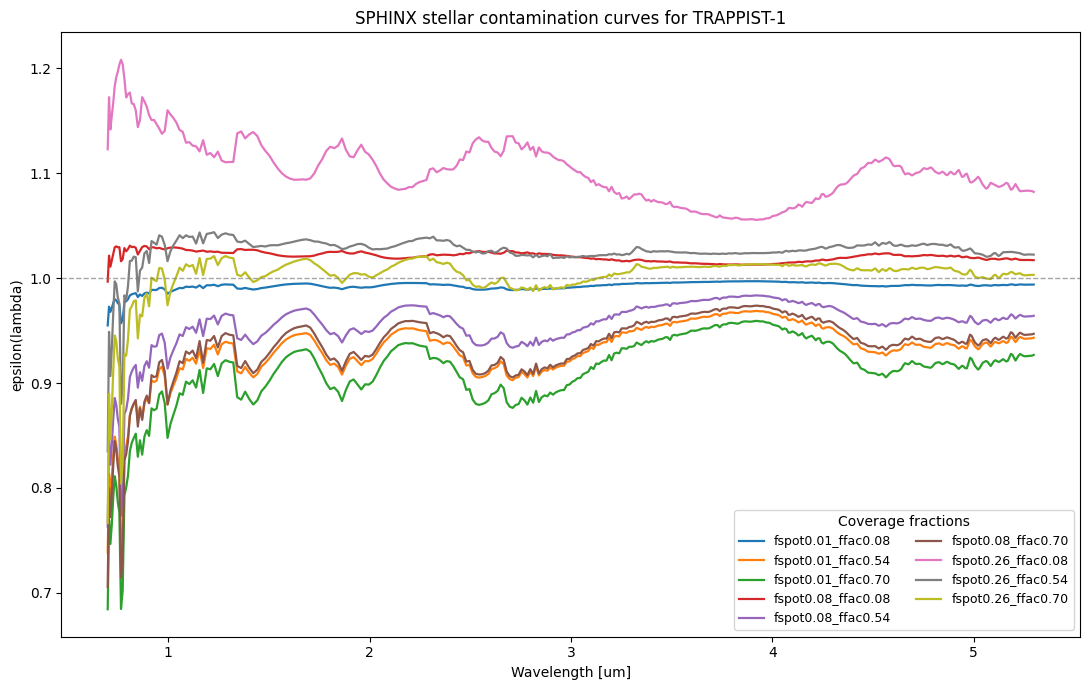

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

for filename in generated_files:
    path = ROOT / filename
    data = np.loadtxt(path)
    plt.plot(data[:, 0], data[:, 1], linewidth=1.6, label=filename.replace("sphinx_TRAPPIST-1_contam_", "").replace(".txt", ""))

plt.axhline(1.0, color="0.5", linestyle="--", linewidth=1.0, alpha=0.7)
plt.xlabel("Wavelength [um]")
plt.ylabel("epsilon(lambda)")
plt.title("SPHINX stellar contamination curves for TRAPPIST-1")
plt.legend(title="Coverage fractions", fontsize=9, title_fontsize=10, ncol=2)
plt.tight_layout()
plt.show()
